<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec08_decision_tree_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 결정 트리 (Decision Tree) 실습

이 실습에서는 결정 트리 알고리즘을 순서대로 구현하고 비교합니다:
1. ID3 — Entropy와 Information Gain을 직접 구현하여 결정 트리 구축
2. C4.5 — sklearn을 활용한 엔트로피 기반 분류 및 과적합 분석
3. CART — sklearn을 활용한 Gini Index 기반 분류와 결정 경계 시각화
4. Random Forest — 앙상블 학습과 단일 DT의 과적합 비교

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주


In [2]:
#@title { vertical-output: true}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)
print("Libraries loaded")

Libraries loaded


---
## Part 1: 데이터 준비

- **날씨 데이터셋**: ID3 직접 구현에 사용 (범주형 특성, 14개 샘플)
- **Iris 데이터셋**: C4.5 / CART / Random Forest sklearn 실습에 사용 (연속형 특성, 150개)

---

In [3]:
#@title { vertical-output: true}
# 날씨 데이터셋 (강의 예제 — 14 샘플, 범주형 특성)
weather_data = {
    'Outlook':     ['sunny','sunny','overcast','rain','rain','rain','overcast',
                    'sunny','sunny','rain','sunny','overcast','overcast','rain'],
    'Temperature': ['hot','hot','hot','mild','cool','cool','cool','mild',
                    'cool','mild','mild','mild','hot','mild'],
    'Humidity':    ['high','high','high','high','normal','normal','normal','high',
                    'normal','normal','normal','high','normal','high'],
    'Windy':       [False,True,False,False,False,True,True,False,
                    False,False,True,True,False,True],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No',
                    'Yes','Yes','Yes','Yes','Yes','No']
}
df = pd.DataFrame(weather_data)
feat_names    = ['Outlook', 'Temperature', 'Humidity', 'Windy']
X_weather_cat = df[feat_names].values
y_weather     = (df['Play'] == 'Yes').astype(int).values  # No=0, Yes=1

print("Weather dataset (14 samples):")
print(df.to_string())
print(f"\nPlay: No={sum(y_weather==0)}, Yes={sum(y_weather==1)}")

Weather dataset (14 samples):
     Outlook Temperature Humidity  Windy Play
0      sunny         hot     high  False   No
1      sunny         hot     high   True   No
2   overcast         hot     high  False  Yes
3       rain        mild     high  False  Yes
4       rain        cool   normal  False  Yes
5       rain        cool   normal   True   No
6   overcast        cool   normal   True  Yes
7      sunny        mild     high  False   No
8      sunny        cool   normal  False  Yes
9       rain        mild   normal  False  Yes
10     sunny        mild   normal   True  Yes
11  overcast        mild     high   True  Yes
12  overcast         hot   normal  False  Yes
13      rain        mild     high   True   No

Play: No=5, Yes=9


In [4]:
#@title { vertical-output: true}
# Iris 데이터셋 로드 및 훈련/테스트 분할 (연속형 특성)
iris          = load_iris()
X_iris, y_iris = iris.data, iris.target
feature_names  = iris.feature_names
class_names    = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)
print("Iris Dataset")
print(f"  Total  : {X_iris.shape}")
print(f"  Train  : {X_train.shape}")
print(f"  Test   : {X_test.shape}")
print(f"  Classes: {class_names}")

Iris Dataset
  Total  : (150, 4)
  Train  : (120, 4)
  Test   : (30, 4)
  Classes: ['setosa' 'versicolor' 'virginica']


---
## Part 2: ID3 직접 구현 (40점)

**ID3 (Iterative Dichotomiser 3)**
- 분기 기준: 엔트로피(Entropy) 기반 정보 이득(Information Gain)
- 범주형(Categorical) 특성에 적합
- 다진 트리(Multi-way split)

$$H(T) = -\sum_k p_k \log_2 p_k \qquad IG(T,a) = H(T) - \sum_{t} p(t)\cdot H(t)$$

---

### 문제 2-1. Entropy 함수 구현 [10점]

**문제:** 레이블 배열 `y`의 엔트로피를 계산하는 `entropy(y)` 함수를 완성하세요.

**예상 결과:**
```
H(Play)       = 0.9403
Pure node     = 0.0000
Uniform 50:50 = 1.0000
```

In [5]:
#@title { vertical-output: true}
def entropy(y):
    """Entropy calculation — Args: y(label array), Returns: float"""
    n = len(y)
    if n == 0: return 0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / n
    # IMPLEMENT HERE: -sum(p * log2(p)) 계산 후 반환
    # np.log2(probs + 1e-10) 을 사용하여 log(0) 방지

    return -np.sum(probs * np.log2(probs + 1e-10))


In [6]:
#@title { vertical-output: true}
print(f"H(Play)       = {entropy(y_weather):.4f}  (expected: 0.9403)")
print(f"Pure node     = {entropy(np.array([1,1,1,1])):.4f}  (expected: 0.0000)")
print(f"Uniform 50:50 = {entropy(np.array([0,0,0,1,1,1])):.4f}  (expected: 1.0000)")

H(Play)       = 0.9403  (expected: 0.9403)
Pure node     = -0.0000  (expected: 0.0000)
Uniform 50:50 = 1.0000  (expected: 1.0000)


### 문제 2-2. Information Gain 함수 구현 [10점]

**문제:** 속성 `X_col`로 분할했을 때의 정보 이득을 계산하는 `information_gain(y, X_col)` 함수를 완성하세요.

**예상 결과:**
```
IG(Play, Outlook)     = 0.2467  ← 최대 → 루트 노드
IG(Play, Humidity)    = 0.1518
IG(Play, Windy)       = 0.0481
IG(Play, Temperature) = 0.0292
```

In [7]:
#@title { vertical-output: true}
def information_gain(y, X_col):
    """Information Gain — Args: y, X_col, Returns: float"""
    n = len(y)
    parent_ent = entropy(y)
    values, counts = np.unique(X_col, return_counts=True)
    weighted = 0
    for v, c in zip(values, counts):
        # IMPLEMENT HERE: 가중 엔트로피를 weighted에 누적
        # 수식: weighted += (c / n) * entropy(y[X_col == v])
        weighted += (c / n) * entropy(y[X_col == v])

    # IMPLEMENT HERE: 정보 이득 반환 (parent_ent - weighted)
    return parent_ent - weighted


In [8]:
#@title { vertical-output: true}
print("Information Gain per feature:")
print("-" * 42)
ig_res = {}
for feat in feat_names:
    ig = information_gain(y_weather, df[feat].values)
    ig_res[feat] = ig
    print(f"  IG(Play, {feat:12s}) = {ig:.4f}")
best = max(ig_res, key=ig_res.get)
print(f"\n-> Root node: {best}  (IG = {ig_res[best]:.4f})")

Information Gain per feature:
------------------------------------------
  IG(Play, Outlook     ) = 0.2467
  IG(Play, Temperature ) = 0.0292
  IG(Play, Humidity    ) = 0.1518
  IG(Play, Windy       ) = 0.0481

-> Root node: Outlook  (IG = 0.2467)


### 문제 2-3. build_id3() 재귀 구현 [15점]

**문제:** ID3 알고리즘으로 결정 트리를 재귀 구축하는 `build_id3()` 함수를 완성하세요.

**구현 요구사항:**
1. 정지 조건: 레이블이 모두 같으면 리프 노드 반환
2. 정지 조건: 남은 특성 없음 또는 max_depth 도달 시 다수결 리프
3. `information_gain` 최대인 특성 선택
4. 선택된 특성의 각 고유값으로 재귀 분기

**예상 결과:**
```
Root: Outlook  (IG = 0.2467)
Branches: ['overcast', 'rain', 'sunny']
```

In [13]:
#@title { vertical-output: true}
def build_id3(X, y, feature_indices, feature_names, depth=0, max_depth=10):
    """ID3 tree builder — Returns: tree node dict"""
    # 정지 조건 1: 레이블이 모두 같으면 리프 반환
    if len(np.unique(y)) == 1:
        return {'leaf': True, 'class': int(y[0]), 'count': len(y)}
    # 정지 조건 2: 남은 특성 없음 또는 최대 깊이 도달
    if len(feature_indices) == 0 or depth >= max_depth:
        return {'leaf': True, 'class': int(np.bincount(y).argmax()), 'count': len(y)}
    # IMPLEMENT HERE: 정보 이득 최대 특성 인덱스를 best_idx에 저장
    # max(feature_indices, key=lambda i: information_gain(y, X[:, i])) 활용
    best_idx  = max(feature_indices, key=lambda i: information_gain(y, X[:, i]))
    best_name = feature_names[best_idx]
    ig_val    = information_gain(y, X[:, best_idx])
    node      = {'leaf': False, 'feature': best_name, 'feature_idx': best_idx,
                 'ig': ig_val, 'children': {}}
    # IMPLEMENT HERE: 선택된 특성을 제외한 remaining 리스트 작성
    remaining = [i for i in feature_indices if i != best_idx]
    # IMPLEMENT HERE: 각 고유값으로 재귀 분기 — build_id3 재귀 호출
    for val in np.unique(X[:, best_idx]):
        mask = X[:, best_idx] == val
        node['children'][val] = build_id3(X[mask], y[mask], remaining, feature_names, depth+1, max_depth)
    return node

id3_tree = build_id3(X_weather_cat, y_weather,
                     list(range(len(feat_names))), feat_names)
print(f"Root feature: {id3_tree['feature']}")
print(f"Root IG     : {id3_tree['ig']:.4f} ")
print(f"Branches    : {list(id3_tree['children'].keys())}")

Root feature: Outlook
Root IG     : 0.2467 
Branches    : ['overcast', 'rain', 'sunny']


### 문제 2-4. predict_id3() 구현 [5점]

**문제:** 구축한 트리로 단일 샘플을 예측하는 `predict_id3()` 함수를 완성하세요.

**예상 결과:**
```
Accuracy: 1.0000  (ID3는 훈련 데이터에 완벽히 적합)
```

In [26]:
#@title { vertical-output: true}
def predict_id3(tree, x):
    """ID3 tree predictor — Args: tree, x (single sample)"""
    # IMPLEMENT HERE: 리프이면 tree['class'] 반환
    if tree['leaf']:
        return tree['class']
    val = x[tree['feature_idx']]
    # 내부 노드이면 x[tree['feature_idx']] 값으로 자식 선택 후 재귀 호출
    if val not in tree['children']:
        return predict_id3(list(tree['children'].values())[0], x)
    # 훈련 시 없던 값은 list(tree['children'].values())[0] 으로 처리
    return predict_id3(tree['children'][val], x)


y_pred  = np.array([predict_id3(id3_tree, x) for x in X_weather_cat])
acc_id3 = np.mean(y_pred == y_weather)
lbl     = ['No', 'Yes']
print("ID3 Predictions (Weather dataset):")
for i, (p, t) in enumerate(zip(y_pred, y_weather)):
    print(f"  [{i+1:2d}] pred={lbl[p]}, true={lbl[t]}  {'O' if p==t else 'X'}")
print(f"\nAccuracy: {acc_id3:.4f}  (expected: 1.0000)")

ID3 Predictions (Weather dataset):
  [ 1] pred=No, true=No  O
  [ 2] pred=No, true=No  O
  [ 3] pred=Yes, true=Yes  O
  [ 4] pred=Yes, true=Yes  O
  [ 5] pred=Yes, true=Yes  O
  [ 6] pred=No, true=No  O
  [ 7] pred=Yes, true=Yes  O
  [ 8] pred=No, true=No  O
  [ 9] pred=Yes, true=Yes  O
  [10] pred=Yes, true=Yes  O
  [11] pred=Yes, true=Yes  O
  [12] pred=Yes, true=Yes  O
  [13] pred=Yes, true=Yes  O
  [14] pred=No, true=No  O

Accuracy: 1.0000  (expected: 1.0000)


### ID3 트리 시각화

아래 `plot_id3()` 함수를 실행하여 구축한 ID3 결정 트리를 시각화하세요.

**확인 포인트:**
- 루트 노드: Outlook (IG가 가장 높은 특성)
- 내부 노드(파란색): 특성명 + IG 값
- 리프 노드: 클래스명(No=빨강, Yes=초록) + 샘플 수
- 엣지 레이블: 각 분기 조건값

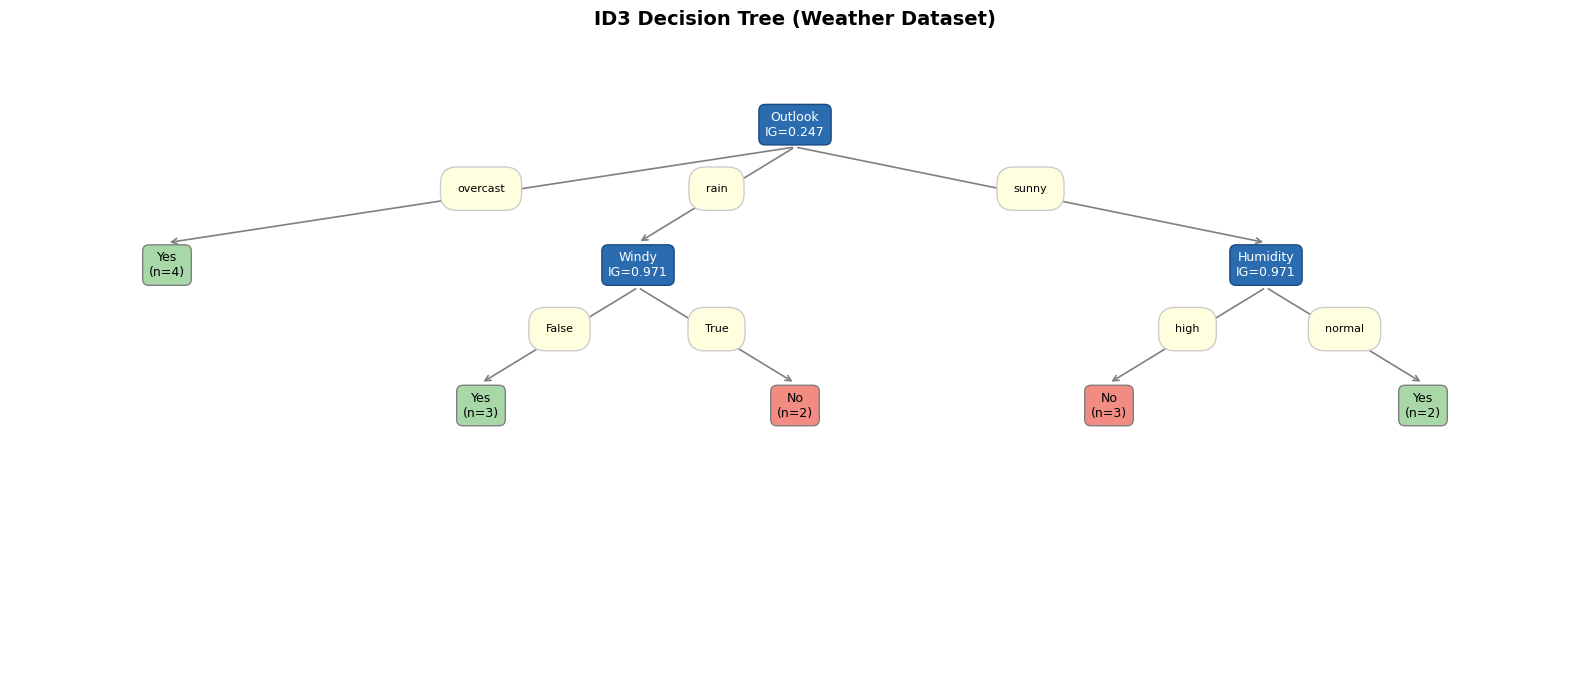

In [11]:
#@title { vertical-output: true}
def plot_id3(tree, class_names=None, title='ID3 Decision Tree'):
    """ID3 tree visualizer using matplotlib"""
    fig, ax = plt.subplots(figsize=(16, 7))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

    def count_leaves(node):
        if node['leaf']: return 1
        return sum(count_leaves(c) for c in node['children'].values())

    def draw(node, x, y, x0, x1, pxy=None, elabel=''):
        if pxy:
            ax.annotate('', xy=(x, y+0.035), xytext=(pxy[0], pxy[1]-0.035),
                        arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
            ax.text((pxy[0]+x)/2, (pxy[1]+y)/2+0.005, str(elabel),
                    ha='center', fontsize=8,
                    bbox=dict(facecolor='lightyellow', edgecolor='#ccc', pad=1.5, boxstyle='round'))
        if node['leaf']:
            cls = class_names[node['class']] if class_names else str(node['class'])
            fc  = '#f28b82' if node['class'] == 0 else '#a8d8a8'
            ax.text(x, y, f"{cls}\n(n={node['count']})", ha='center', va='center', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor=fc, edgecolor='gray'))
        else:
            ax.text(x, y, f"{node['feature']}\nIG={node['ig']:.3f}",
                    ha='center', va='center', fontsize=9, color='white',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='#2b6cb0', edgecolor='#1a4a80'))
            ch  = list(node['children'].items())
            lcs = [count_leaves(c) for _, c in ch]; tot = sum(lcs); cx = x0
            for (val, child), lc in zip(ch, lcs):
                nx = cx + (x1-x0)*lc/tot
                draw(child, (cx+nx)/2, y-0.22, cx, nx, (x, y), val)
                cx = nx

    draw(id3_tree, 0.5, 0.87, 0.0, 1.0)
    plt.title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout(); plt.show()

plot_id3(id3_tree, class_names=['No','Yes'],
         title='ID3 Decision Tree (Weather Dataset)')

---
## Part 3: C4.5 (sklearn) (20점)

**C4.5**는 ID3의 확장 알고리즘입니다:
- 분기 기준: **정보 이득 비율(Gain Ratio)** = $\frac{IG(T,a)}{H_\text{split}(a)}$
- **연속형 특성** 처리 가능 (임계값 기반 이진 분할)
- 결측값 처리 가능

sklearn의 `criterion='entropy'`는 C4.5와 유사한 엔트로피 기반 분기를 사용합니다.
Iris 데이터셋처럼 **연속형 특성**에서 C4.5의 강점이 드러납니다.

---

### 문제 3-1. C4.5 학습 및 과적합 분석 [15점]

**문제 (1):** `criterion='entropy'`로 C4.5 스타일 `DecisionTreeClassifier`를 학습하세요.

**문제 (2):** `max_depth`를 1~10으로 변화시키며 훈련/테스트 정확도 변화를 분석하세요.

**예상 결과:**
```
C4.5-style Decision Tree (criterion='entropy')
  Train accuracy: 1.0000
  Test  accuracy: 1.0000

max_depth | Train acc | Test acc
    1     |  0.6750  |  0.6333
    3     |  0.9583  |  1.0000
   10     |  1.0000  |  1.0000
```

In [16]:
#@title { vertical-output: true}
# IMPLEMENT HERE: criterion='entropy', random_state=42 로 DecisionTreeClassifier 생성 및 학습
c45 = DecisionTreeClassifier(criterion='entropy', random_state=42)
c45.fit(X_train, y_train)

train_acc_c45 = accuracy_score(y_train, c45.predict(X_train))
test_acc_c45  = accuracy_score(y_test,  c45.predict(X_test))
print("C4.5-style Decision Tree (criterion='entropy')")
print(f"  Train accuracy: {train_acc_c45:.4f}")
print(f"  Test  accuracy: {test_acc_c45:.4f}")

# IMPLEMENT HERE: max_depth를 1~10으로 변화시키며 정확도 수집
depths    = range(1, 11)
c45_train = []
c45_test  = []
for d in depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    # IMPLEMENT HERE: 학습 후 c45_train, c45_test 에 정확도 추가
    dt.fit(X_train, y_train)
    c45_train.append(accuracy_score(y_train, dt.predict(X_train)))
    c45_test.append(accuracy_score(y_test, dt.predict(X_test)))


print("\nmax_depth | Train acc | Test acc")
print("-" * 36)
for d, tr, te in zip(depths, c45_train, c45_test):
    print(f"   {d:2d}     |  {tr:.4f}  |  {te:.4f}")

C4.5-style Decision Tree (criterion='entropy')
  Train accuracy: 1.0000
  Test  accuracy: 1.0000

max_depth | Train acc | Test acc
------------------------------------
    1     |  0.6750  |  0.6333
    2     |  0.9500  |  0.9667
    3     |  0.9583  |  1.0000
    4     |  0.9750  |  1.0000
    5     |  0.9917  |  1.0000
    6     |  1.0000  |  1.0000
    7     |  1.0000  |  1.0000
    8     |  1.0000  |  1.0000
    9     |  1.0000  |  1.0000
   10     |  1.0000  |  1.0000


### 문제 3-2. C4.5 트리 시각화 [5점]

**문제:** 아래 코드를 실행하여 `max_depth=3`으로 학습한 C4.5 트리를 시각화하세요.

**확인 포인트:** 연속형 특성의 임계값 기반 이진 분할 확인 (예: `petal length (cm) <= 2.45`)

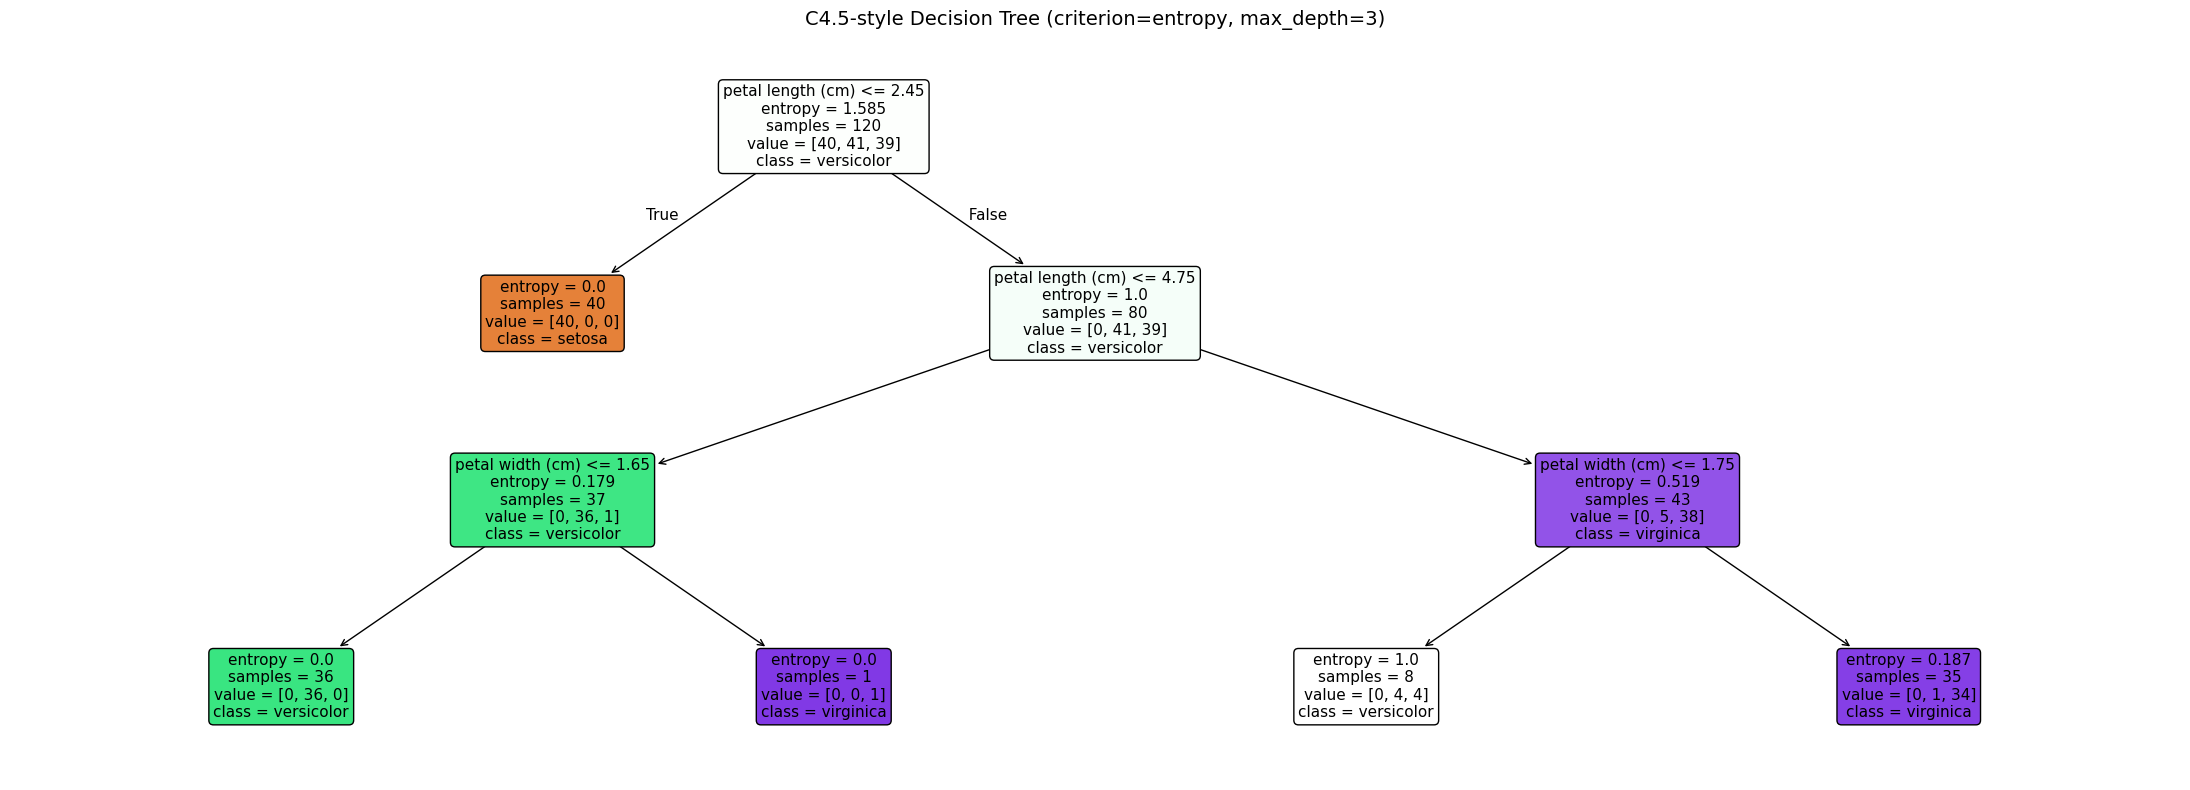

In [17]:
#@title { vertical-output: true}
# C4.5 트리 시각화 (max_depth=3)
c45_vis = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
c45_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(c45_vis, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, ax=ax, fontsize=11)
plt.title("C4.5-style Decision Tree (criterion=entropy, max_depth=3)", fontsize=14)
plt.tight_layout(); plt.show()

---
## Part 4: CART (sklearn) (20점)

**CART (Classification and Regression Trees)**
- 분기 기준: **지니 지수(Gini Index)**
- **이진 트리(Binary Tree)** — 항상 두 자식으로 분기
- 연속형/범주형 특성 모두 처리

$$GI = 1 - \sum_j p_j^2 \qquad (\text{range: }[0,\ 0.5])$$

이 파트에서는 `make_moons` 2D 데이터셋을 사용하여 CART의 결정 경계를 직관적으로 확인합니다.

---

### 문제 4-1. Gini Index 함수 구현 [5점]

**문제:** 레이블 배열 `y`의 지니 지수를 계산하는 `gini_index(y)` 함수를 완성하세요.

**예상 결과:**
```
Gini(Play) = 0.4592
Pure node  = 0.0000
Uniform    = 0.5000
```

In [18]:
#@title { vertical-output: true}
def gini_index(y):
    """Gini Index calculation — Args: y, Returns: float"""
    n = len(y)
    if n == 0: return 0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / n
    # IMPLEMENT HERE: 1 - sum(p^2) 계산 후 반환
    return 1 - np.sum(probs**2)

print(f"Gini(Play) = {gini_index(y_weather):.4f}  (expected: 0.4592)")
print(f"Pure node  = {gini_index(np.array([1,1,1,1])):.4f}  (expected: 0.0000)")
print(f"Uniform    = {gini_index(np.array([0,0,0,1,1,1])):.4f}  (expected: 0.5000)")
print()
print("Entropy vs Gini Index (weather data):")
print(f"  Entropy : {entropy(y_weather):.4f}  range [0, 1]")
print(f"  Gini    : {gini_index(y_weather):.4f}  range [0, 0.5]")

Gini(Play) = 0.4592  (expected: 0.4592)
Pure node  = 0.0000  (expected: 0.0000)
Uniform    = 0.5000  (expected: 0.5000)

Entropy vs Gini Index (weather data):
  Entropy : 0.9403  range [0, 1]
  Gini    : 0.4592  range [0, 0.5]


In [19]:
#@title { vertical-output: true}
# Part 4 전용 데이터셋 — 비선형 경계 확인에 적합한 make_moons
from sklearn.datasets import make_moons
X_2d, y_2d = make_moons(n_samples=300, noise=0.25, random_state=42)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_2d, y_2d, test_size=0.3, random_state=42
)
print("make_moons dataset")
print(f"  Total: {X_2d.shape}")
print(f"  Train: {X_tr2.shape}")
print(f"  Test : {X_te2.shape}")

make_moons dataset
  Total: (300, 2)
  Train: (210, 2)
  Test : (90, 2)


### 문제 4-2. CART 학습 (criterion='gini') [10점]

**문제:** `criterion='gini'`로 CART 스타일의 `DecisionTreeClassifier`를 학습하고 정확도를 출력하세요.

**예상 결과:**
```
CART (criterion='gini', make_moons)
  Train accuracy: 1.0000
  Test  accuracy: ~0.922
```

In [20]:
#@title { vertical-output: true}
# IMPLEMENT HERE: criterion='gini', random_state=42 로 DecisionTreeClassifier 생성 및 학습
cart = DecisionTreeClassifier(criterion='gini', random_state=42)
cart.fit(X_tr2, y_tr2)

train_acc_cart = accuracy_score(y_tr2, cart.predict(X_tr2))
test_acc_cart  = accuracy_score(y_te2, cart.predict(X_te2))
print("CART (criterion='gini', make_moons)")
print(f"  Train accuracy: {train_acc_cart:.4f}")
print(f"  Test  accuracy: {test_acc_cart:.4f}")

CART (criterion='gini', make_moons)
  Train accuracy: 1.0000
  Test  accuracy: 0.9222


### 문제 4-3. CART 결정 경계 시각화 [5점]

**문제:** 아래 코드를 실행하여 `max_depth`에 따른 CART의 결정 경계 변화를 확인하세요.

**관찰 포인트:**
- CART는 항상 축에 평행한 이진 분할(binary split)을 수행
- `max_depth`가 깊어질수록 경계가 복잡해지며 과적합 발생
- 정확도 수치로 적정 깊이 확인

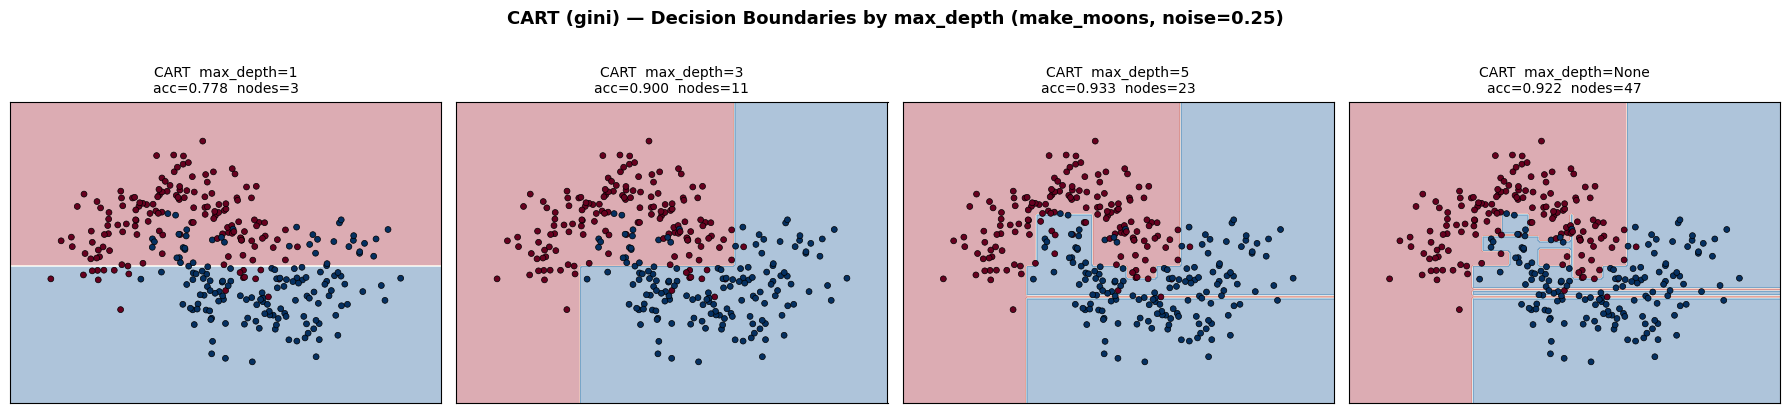

In [21]:
#@title { vertical-output: true}
def plot_cart_boundary(ax, model, X, y, X_test, y_test, title):
    # 결정 경계 메시 생성
    h = 0.03
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap=plt.cm.RdBu)
    ax.scatter(X[:,0], X[:,1], c=y,
               cmap=plt.cm.RdBu, edgecolors='k', s=18, linewidths=0.5)
    acc = accuracy_score(y_test, model.predict(X_test))
    n   = model.tree_.node_count
    ax.set_title(f"{title}\nacc={acc:.3f}  nodes={n}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, depth in zip(axes, [1, 3, 5, None]):
    dt = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt.fit(X_tr2, y_tr2)
    plot_cart_boundary(ax, dt, X_2d, y_2d, X_te2, y_te2,
                       f"CART  max_depth={depth}")

plt.suptitle('CART (gini) — Decision Boundaries by max_depth (make_moons, noise=0.25)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 5: Random Forest (20점)

**Random Forest**는 여러 CART 트리를 앙상블하는 방법입니다:
- **Bootstrap Sampling**: 각 트리마다 복원 추출로 서로 다른 훈련 데이터 사용
- **Feature Randomness**: 각 분기마다 무작위로 일부 특성만 고려
- **Soft Voting**: 각 트리의 예측 확률 평균으로 최종 예측

> **이 파트에서는 Iris 대신 더 복잡한 합성 데이터셋을 사용합니다.**  
> 노이즈가 포함된 20차원 데이터에서 단일 DT의 과적합과 RF의 앙상블 효과를 비교합니다.

---

In [22]:
#@title { vertical-output: true}
# Part 5 전용 데이터셋 — 노이즈 포함 합성 분류 문제
from sklearn.datasets import make_classification
X_rf, y_rf = make_classification(
    n_samples=600, n_features=20, n_informative=8, n_redundant=5,
    flip_y=0.05, random_state=42   # flip_y=0.05: 5% 레이블 노이즈 추가
)
rf_feat_names = [f'feature_{i:02d}' for i in range(20)]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.3, random_state=42
)
print("Dataset for Part 5 (noisy classification)")
print(f"  Features : 20 (informative=8, redundant=5, noise flip=5%)")
print(f"  Train    : {X_train_rf.shape}")
print(f"  Test     : {X_test_rf.shape}")

Dataset for Part 5 (noisy classification)
  Features : 20 (informative=8, redundant=5, noise flip=5%)
  Train    : (420, 20)
  Test     : (180, 20)


### 문제 5-1. Random Forest 학습 [10점]

**문제:** `RandomForestClassifier(n_estimators=100, random_state=42)`를 학습하고 정확도를 출력하세요.

**예상 결과:**
```
Random Forest (n_estimators=100)
  Train accuracy: 1.0000
  Test  accuracy: ~0.844  (단일 DT 최고치 ~0.706 보다 크게 높음)
```

In [24]:
#@title { vertical-output: true}
# IMPLEMENT HERE: n_estimators=100, random_state=42 로 RandomForestClassifier 생성 및 학습
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train_rf)

train_acc_rf = accuracy_score(y_train_rf, rf.predict(X_train_rf))
test_acc_rf  = accuracy_score(y_test_rf,  rf.predict(X_test_rf))
print("Random Forest (n_estimators=100)")
print(f"  Train accuracy: {train_acc_rf:.4f}")
print(f"  Test  accuracy: {test_acc_rf:.4f}")

Random Forest (n_estimators=100)
  Train accuracy: 1.0000
  Test  accuracy: 0.8444


### 문제 5-2. DT 과적합 vs RF 비교 [10점]

**문제:** 아래 코드를 실행하여 단일 DT(다양한 max_depth)와 RF의 테스트 정확도를 비교하세요.

**관찰 포인트:**
- DT: `max_depth`가 깊어질수록 훈련 정확도는 1.0에 수렴하지만 테스트 정확도는 하락 (과적합)
- RF: 앙상블 효과로 단일 DT보다 테스트 정확도가 크게 높음

Single DT vs Random Forest:
 max_depth |  Train |   Test
--------------------------------
         1 | 0.7357 | 0.6722  
         3 | 0.7405 | 0.6778  
         5 | 0.8048 | 0.6500  <- overfit!
        10 | 0.9714 | 0.7056  <- overfit!
      None | 1.0000 | 0.7000  <- overfit!
  RF(n=100) | 1.0000 | 0.8444  <- ensemble


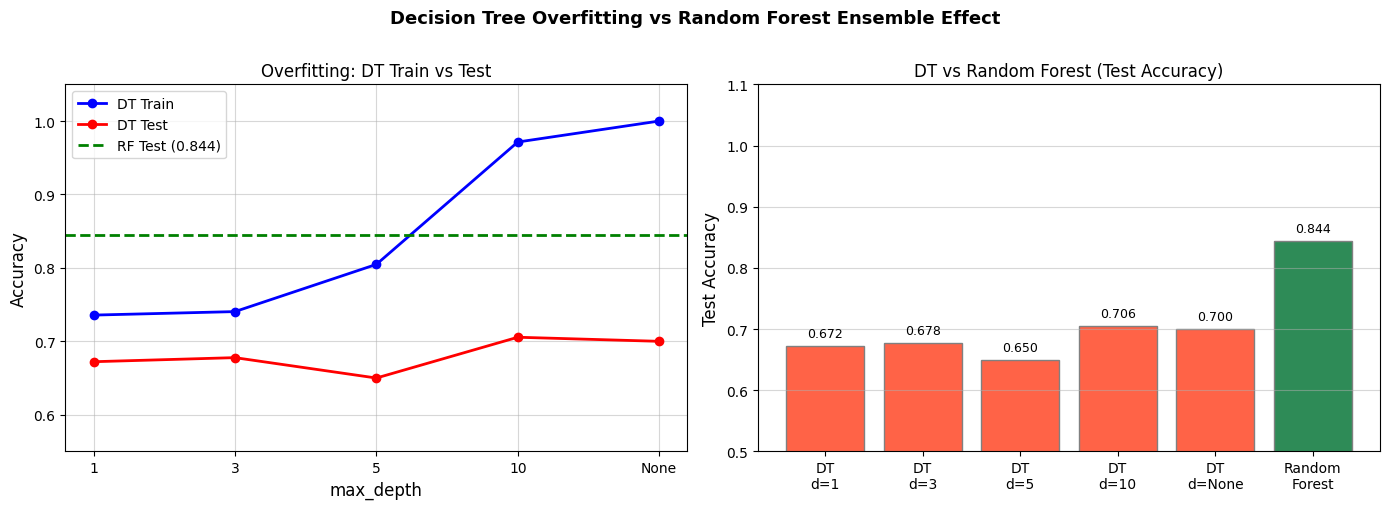

In [25]:
#@title { vertical-output: true}
# DT(다양한 max_depth)와 RF 테스트 정확도 비교
cmp_depths = [1, 3, 5, 10, None]
dt_train   = []
dt_test    = []
for d in cmp_depths:
    dt = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    dt.fit(X_train_rf, y_train_rf)
    dt_train.append(accuracy_score(y_train_rf, dt.predict(X_train_rf)))
    dt_test.append(accuracy_score(y_test_rf,   dt.predict(X_test_rf)))

print("Single DT vs Random Forest:")
print(f"{'max_depth':>10} | {'Train':>6} | {'Test':>6}")
print("-" * 32)
for d, tr, te in zip(cmp_depths, dt_train, dt_test):
    print(f"  {str(d):>8} | {tr:.4f} | {te:.4f}  {'<- overfit!' if tr - te > 0.15 else ''}")
print(f"  {'RF(n=100)':>8} | {train_acc_rf:.4f} | {test_acc_rf:.4f}  <- ensemble")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 훈련 vs 테스트 정확도 (과적합 시각화)
x_labels = [str(d) for d in cmp_depths]
ax1.plot(x_labels, dt_train, 'b-o', label='DT Train', linewidth=2)
ax1.plot(x_labels, dt_test,  'r-o', label='DT Test',  linewidth=2)
ax1.axhline(test_acc_rf, color='green', linestyle='--', linewidth=2,
            label=f'RF Test ({test_acc_rf:.3f})')
ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('Accuracy',  fontsize=12)
ax1.set_title('Overfitting: DT Train vs Test', fontsize=12)
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.5); ax1.set_ylim(0.55, 1.05)

# 오른쪽: 테스트 정확도 막대 비교
bar_labels = [f"DT\nd={d}" for d in cmp_depths] + ['Random\nForest']
bar_accs   = dt_test + [test_acc_rf]
bar_colors = ['tomato']*len(cmp_depths) + ['seagreen']
bars = ax2.bar(bar_labels, bar_accs, color=bar_colors, edgecolor='gray')
ax2.set_ylim(0.5, 1.1)
ax2.set_ylabel('Test Accuracy', fontsize=12)
ax2.set_title('DT vs Random Forest (Test Accuracy)', fontsize=12)
for bar, acc in zip(bars, bar_accs):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
ax2.grid(axis='y', alpha=0.5)

plt.suptitle('Decision Tree Overfitting vs Random Forest Ensemble Effect',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, **모든 코드 셀을 처음부터 순서대로 실행**하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일 (실행 결과 포함)
   - `.pdf` 파일 (파일 → 인쇄 → PDF로 저장)
3. **파일명:** `decision_tree_학번_이름.ipynb`, `decision_tree_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의: 기한 내에 제출하지 않으면 감점이 있습니다.**

---